In [ ]:
# Cell 1: Import Libraries

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern

# Setting default figure size for plots
plt.rcParams["figure.figsize"] = (10, 6)


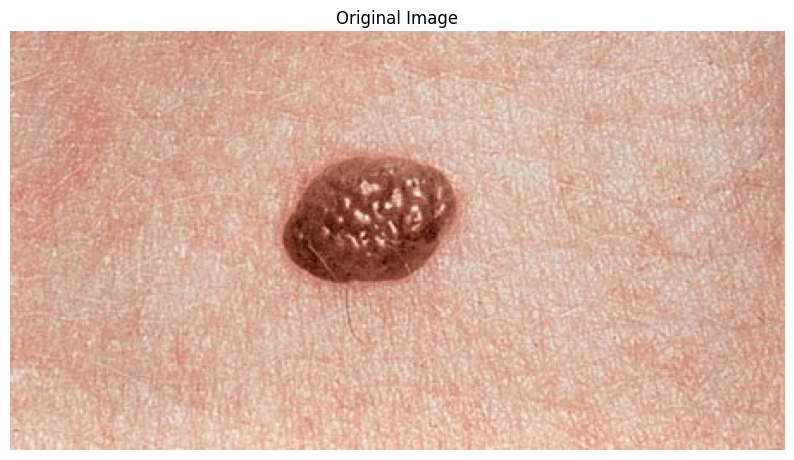

In [ ]:
# Cell 2: Load Image and Display

image_path = r"D:\Final Year Project\ImageProcessing\Images\Melanoma_1.jpeg"  
img = cv2.imread(image_path)

if img is None:
    raise ValueError("Image not found. Check path.")

# Converting BGR to RGB for correct color display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#Display the original image
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off') #hiding axis
plt.show()


In [ ]:
# --- EARLY ROI CROP: Skin Region Only ---

# Convert to YCrCb (robust across skin tones)
ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)

# VERY conservative skin range (do not tighten this)
skin_mask_early = cv2.inRange(
    ycrcb,
    (0, 133, 77),
    (255, 173, 127)
)

# Clean mask slightly (do NOT overdo morphology)
kernel = np.ones((7, 7), np.uint8)
skin_mask_early = cv2.morphologyEx(skin_mask_early, cv2.MORPH_CLOSE, kernel)
skin_mask_early = cv2.morphologyEx(skin_mask_early, cv2.MORPH_OPEN, kernel)


In [ ]:
contours, _ = cv2.findContours(
    skin_mask_early,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

if contours:
    largest_skin = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_skin)

    pad = 20  # conservative padding
    x1 = max(x - pad, 0)
    y1 = max(y - pad, 0)
    x2 = min(x + w + pad, img.shape[1])
    y2 = min(y + h + pad, img.shape[0])

    img = img[y1:y2, x1:x2]


In [ ]:

def remove_hair(gray):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(gray, mask, 3, cv2.INPAINT_TELEA)


In [ ]:
# Cell 3: Compute Laplacian Variance (Sharpness)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale for sharpness check
gray = remove_hair(gray)
laplacian = cv2.Laplacian(gray, cv2.CV_64F) # Compute Laplacian to detect edges and variance of Laplacian (higher = sharper)
lap_var = laplacian.var()

print("Laplacian Variance (Image Sharpness):", lap_var)

# Checking if image is sharp or blurry based on a threshold
sharp_threshold = 100  # Threshold value can be adjusted based on requirements
if lap_var < sharp_threshold:
    print("Warning: Image may be blurry")
else:
    print("Image appears sharp.")


Laplacian Variance (Image Sharpness): 70.28670317612345


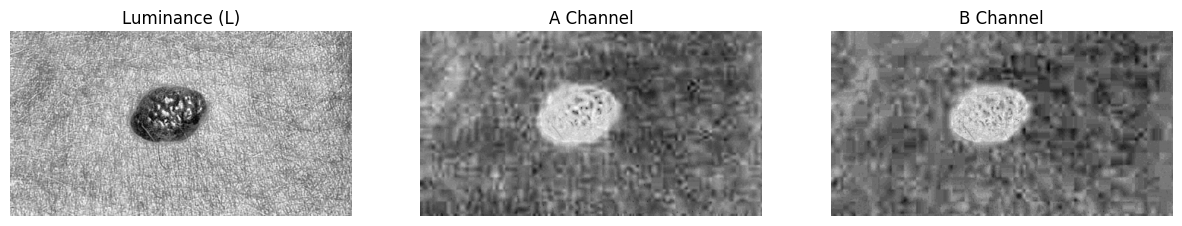

In [ ]:
# Cell 4: Convert to LAB colour space and display channels

# Convert BGR to LAB
lab_img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
L, A, B = cv2.split(lab_img)

# Enhance local contrast (important for subtle lesions & dark skin)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
L = clahe.apply(L)


# Display L, A, B channels separately
#Luminance channel for intenisty/brightness
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(L, cmap='gray')
plt.title("Luminance (L)")
plt.axis('off')


#A channel for green-red axis
plt.subplot(1,3,2)
plt.imshow(A, cmap='gray')
plt.title("A Channel")
plt.axis('off')

#B channel for blue-yellow axis
plt.subplot(1,3,3)
plt.imshow(B, cmap='gray')
plt.title("B Channel")
plt.axis('off')
plt.show()


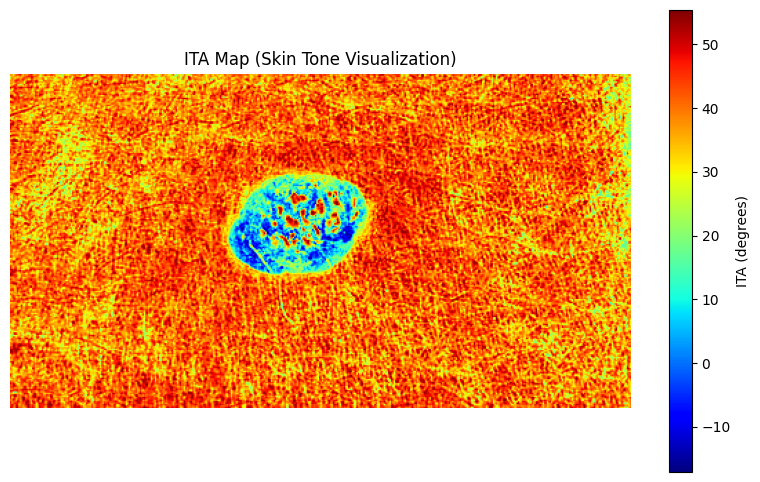

Mean ITA for Skin Regions: 39.284034729003906
Skin Tone (Fitzpatrick Scale): Type III


In [ ]:
L_float = L.astype(np.float32)
B_float = B.astype(np.float32)
ITA = np.arctan2((L_float - 50), B_float) * (180 / np.pi)

plt.imshow(ITA, cmap='jet')
plt.colorbar(label='ITA (degrees)')
plt.title("ITA Map (Skin Tone Visualization)")
plt.axis('off')
plt.show()

skin_ita_low = 10
skin_ita_high = 55
skin_mask = np.where((ITA > skin_ita_low) & (ITA < skin_ita_high), 255, 0).astype(np.uint8)

mean_ita_skin = np.mean(ITA[skin_mask == 255])
print(f"Mean ITA for Skin Regions: {mean_ita_skin}")

if mean_ita_skin > 55:
    skin_tone = "Type I"
elif 41 < mean_ita_skin <= 55:
    skin_tone = "Type II"
elif 28 < mean_ita_skin <= 41:
    skin_tone = "Type III"
elif 10 < mean_ita_skin <= 28:
    skin_tone = "Type IV"
elif -30 < mean_ita_skin <= 10:
    skin_tone = "Type V"
else:
    skin_tone = "Type VI"

print(f"Skin Tone (Fitzpatrick Scale): {skin_tone}")


In [ ]:
def process_light_skin(L, A, B):
    ab = np.stack([A, B], axis=2)
    ab_flat = ab.reshape((-1, 2))
    ab_flat = np.float32(ab_flat)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    K = 2
    _, labels, centers = cv2.kmeans(ab_flat, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    labels = labels.flatten().reshape(A.shape)

    global_L = np.mean(L)
    cluster_scores = []

    for i in range(K):
        cluster_L = np.mean(L[labels == i])
        area = np.sum(labels == i)
        score = abs(cluster_L - global_L) * area
        cluster_scores.append(score)

    lesion_cluster = np.argmax(cluster_scores)

    AB_mask = np.uint8(labels == lesion_cluster) * 255
    return AB_mask


In [ ]:
def process_dark_skin(L, A, B):
    ab = np.stack([A, B], axis=2)
    ab_flat = ab.reshape((-1, 2))
    ab_flat = np.float32(ab_flat)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    K = 3
    _, labels, centers = cv2.kmeans(ab_flat, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    labels = labels.flatten().reshape(A.shape)

    global_L = np.mean(L)
    cluster_scores = []

    for i in range(K):
        cluster_L = np.mean(L[labels == i])
        area = np.sum(labels == i)
        score = abs(cluster_L - global_L) * area
        cluster_scores.append(score)

    lesion_cluster = np.argmax(cluster_scores)


    AB_mask = np.uint8(labels == lesion_cluster) * 255
    return AB_mask


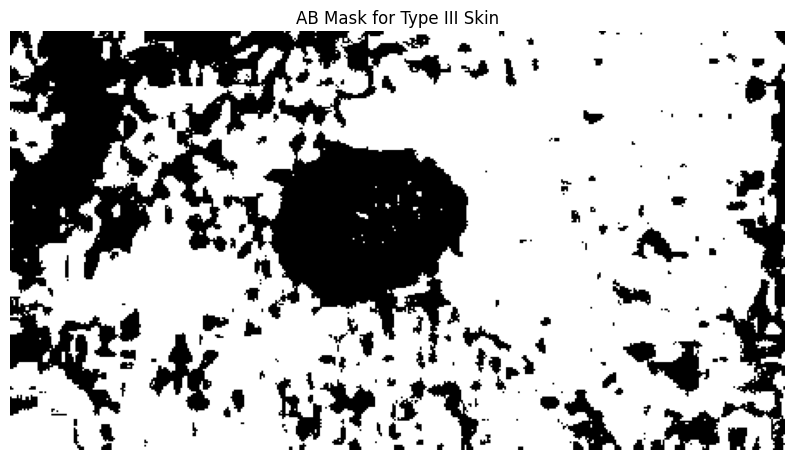

In [ ]:
if skin_tone in ["Type I", "Type II", "Type III"]:
    AB_mask = process_light_skin(L, A, B)
else:  # Type IV, V, and VI
    AB_mask = process_dark_skin(L, A, B)

plt.imshow(AB_mask, cmap='gray')
plt.title(f"AB Mask for {skin_tone} Skin")
plt.axis('off')
plt.show()


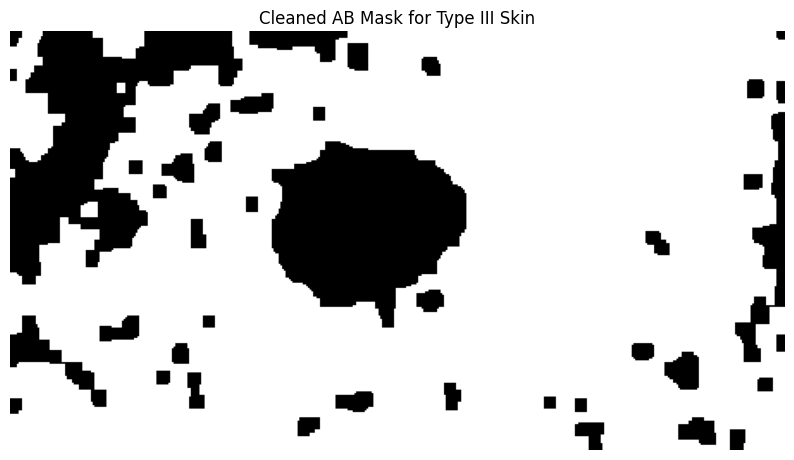

In [ ]:
if skin_tone in ["Type I", "Type II", "Type III"]:
    kernel_close = np.ones((7, 7), np.uint8)
    kernel_open = np.ones((5, 5), np.uint8)
else:  # Type IV, V, and VI
    kernel_close = np.ones((9, 9), np.uint8)
    kernel_open = np.ones((7, 7), np.uint8)

AB_mask_clean = cv2.morphologyEx(AB_mask, cv2.MORPH_CLOSE, kernel_close)
AB_mask_clean = cv2.morphologyEx(AB_mask_clean, cv2.MORPH_OPEN, kernel_open)

plt.imshow(AB_mask_clean, cmap='gray')
plt.title(f"Cleaned AB Mask for {skin_tone} Skin")
plt.axis('off')
plt.show()


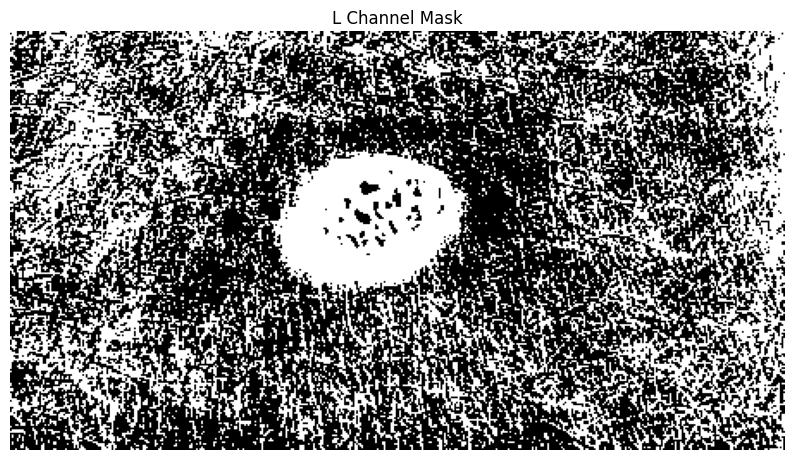

In [ ]:
L_norm = cv2.normalize(L, None, 0, 255, cv2.NORM_MINMAX)

if skin_tone in ["Type I", "Type II", "Type III"]:
    _, L_mask = cv2.threshold(L_norm, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
else:  # Type IV, V, and VI
    L_blur = cv2.GaussianBlur(L_norm, (5, 5), 0)
    L_mask = cv2.adaptiveThreshold(L_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

plt.imshow(L_mask, cmap='gray')
plt.title("L Channel Mask")
plt.axis('off')
plt.show()


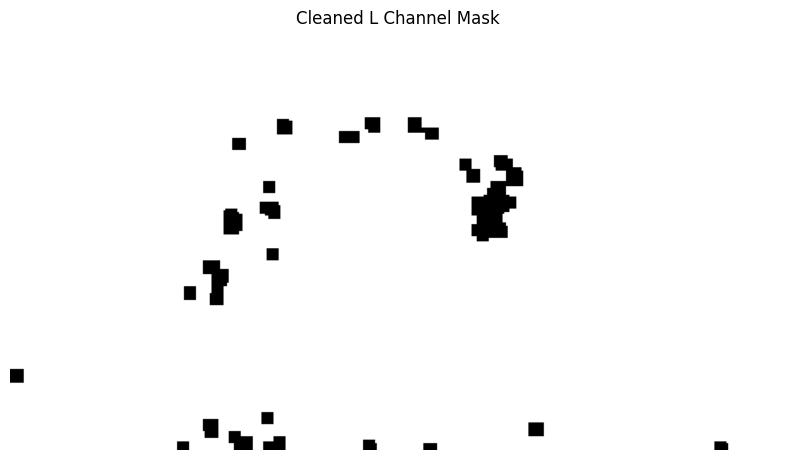

In [ ]:
L_mask_clean = cv2.morphologyEx(L_mask, cv2.MORPH_CLOSE, kernel_close)
L_mask_clean = cv2.morphologyEx(L_mask_clean, cv2.MORPH_OPEN, kernel_open)

plt.imshow(L_mask_clean, cmap='gray')
plt.title("Cleaned L Channel Mask")
plt.axis('off')
plt.show()


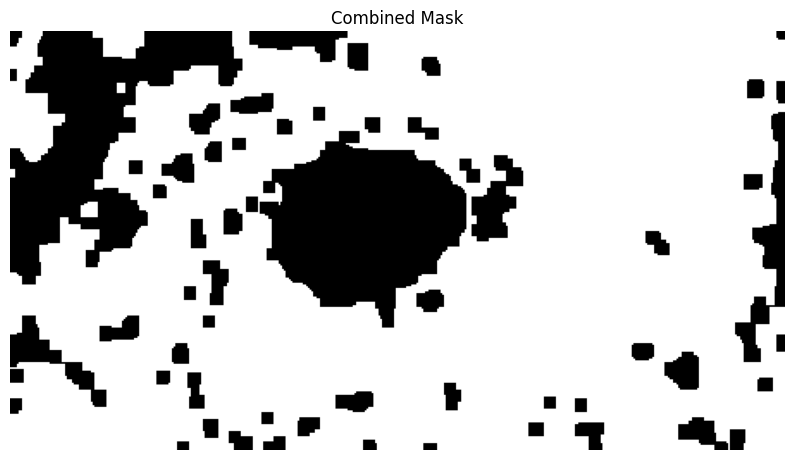

In [ ]:
combined_mask = cv2.bitwise_and(AB_mask_clean, L_mask_clean)


plt.imshow(combined_mask, cmap='gray')
plt.title("Combined Mask")
plt.axis('off')
plt.show()


In [ ]:
contours, _ = cv2.findContours(combined_mask, cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

candidates = []

for cnt in contours:
    area = cv2.contourArea(cnt)
    if 500 < area < 0.5 * combined_mask.size:
        x, y, w, h = cv2.boundingRect(cnt)
        pad = 10
        x1 = max(x - pad, 0)
        y1 = max(y - pad, 0)
        x2 = min(x + w + pad, img.shape[1])
        y2 = min(y + h + pad, img.shape[0])
        crop = img[y1:y2, x1:x2]
        candidates.append(crop)


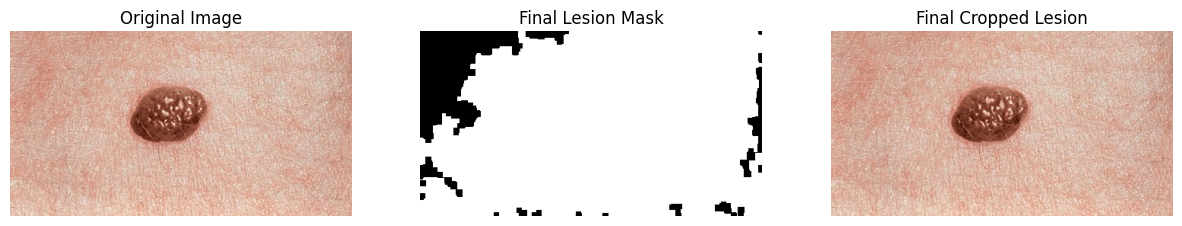

In [ ]:
contours, _ = cv2.findContours(combined_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

def lesion_score(cnt):
    area = cv2.contourArea(cnt)
    if area < 300:
        return 0

    perimeter = cv2.arcLength(cnt, True)
    if perimeter == 0:
        return 0

    circularity = 4 * np.pi * area / (perimeter ** 2)
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = w / h if h != 0 else 0

    return area * circularity / (aspect_ratio + 0.5)

if len(contours) > 0:
    largest_contour = max(contours, key=cv2.contourArea)
    lesion_mask_final = np.zeros_like(combined_mask)
    cv2.drawContours(lesion_mask_final, [largest_contour], -1, 255, -1)

    x, y, w_box, h_box = cv2.boundingRect(largest_contour)
    pad = 5
    x1 = max(x - pad, 0)
    y1 = max(y - pad, 0)
    x2 = min(x + w_box + pad, combined_mask.shape[1])
    y2 = min(y + h_box + pad, combined_mask.shape[0])

    lesion_crop_final = img[y1:y2, x1:x2]

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(lesion_mask_final, cmap='gray')
    plt.title("Final Lesion Mask")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(lesion_crop_final, cv2.COLOR_BGR2RGB))
    plt.title("Final Cropped Lesion")
    plt.axis('off')

    plt.show()



In [ ]:
def resize_and_normalize(lesion_crop_final):
    if lesion_crop_final is not None:
        lesion_resized = cv2.resize(lesion_crop_final, (224, 224))
        lesion_normalized = lesion_resized / 255.0
        print("Lesion resized and normalized for model input:", lesion_normalized.shape)
        return lesion_normalized
    else:
        print("No lesion to resize and normalize.")
        return None

lesion_normalized = resize_and_normalize(lesion_crop_final)


Lesion resized and normalized for model input: (224, 224, 3)


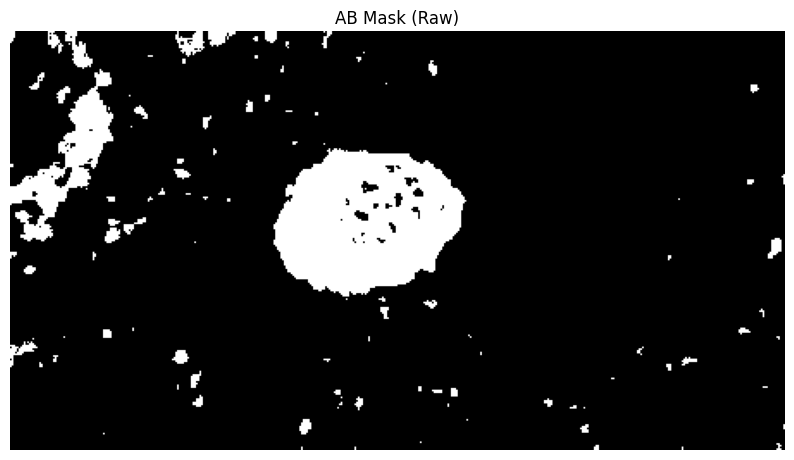

In [ ]:
# Cell 5: AB clustering to generate lesion mask using K-means

ab = np.stack([A, B], axis=2) # Combine A and B channels
ab_flat = ab.reshape((-1, 2)) # flattening for k-means
ab_flat = np.float32(ab_flat) # convert to float32

#Defining criteria and parameters for k-means
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
K = 3 

# Applying k-means clustering
_, labels, centers = cv2.kmeans(ab_flat, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
labels = labels.flatten().reshape(A.shape)

# Identify lesion cluster as the one with darker L values
cluster_means = [np.mean(L[labels == i]) for i in range(K)]
lesion_cluster = np.argmin(cluster_means)

# Creating binary mask for lesion
AB_mask = np.uint8(labels == lesion_cluster) * 255

plt.imshow(AB_mask, cmap='gray')
plt.title("AB Mask (Raw)")
plt.axis('off')
plt.show()


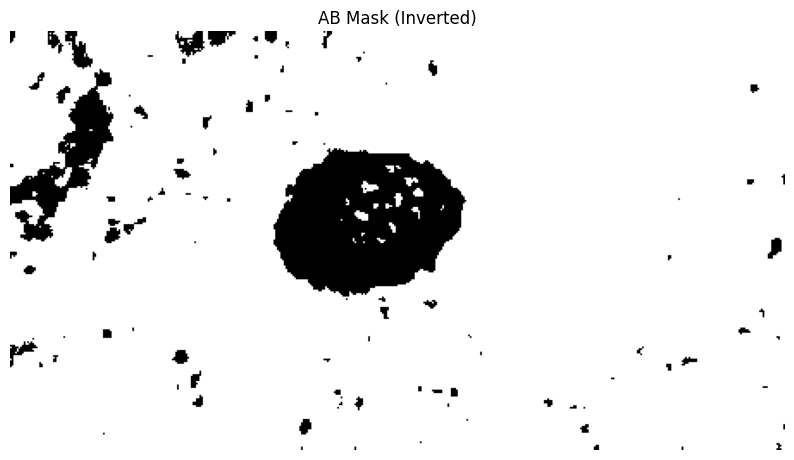

In [ ]:
AB_mask = 255 - AB_mask  # Invert the mask so that the lesion is white and background is black

plt.imshow(AB_mask, cmap='gray')
plt.title("AB Mask (Inverted)")
plt.axis('off')
plt.show()


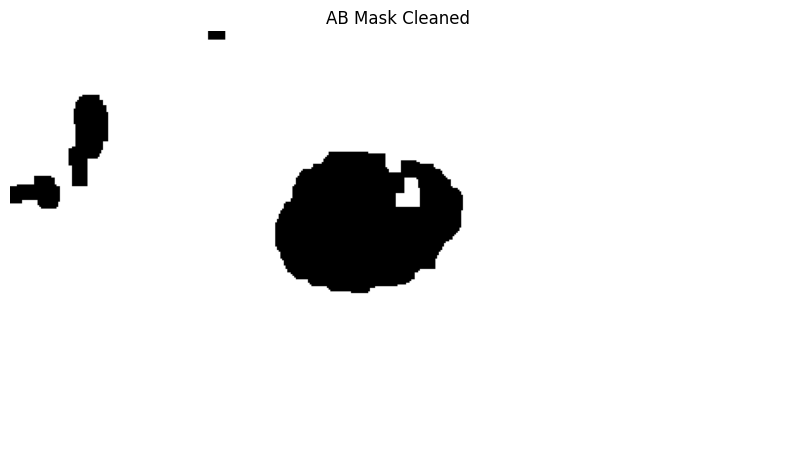

In [ ]:
# Cell 6: Morphological cleanup

#Opening and closing operations to clean up the mask
kernel_close = np.ones((9, 9), np.uint8)
kernel_open = np.ones((7, 7), np.uint8)

# Applying morphological closing and opening to fill holes and remove noise
AB_mask_clean = cv2.morphologyEx(AB_mask, cv2.MORPH_CLOSE, kernel_close)
AB_mask_clean = cv2.morphologyEx(AB_mask_clean, cv2.MORPH_OPEN, kernel_open)

plt.imshow(AB_mask_clean, cmap='gray')
plt.title("AB Mask Cleaned")
plt.axis('off')
plt.show()


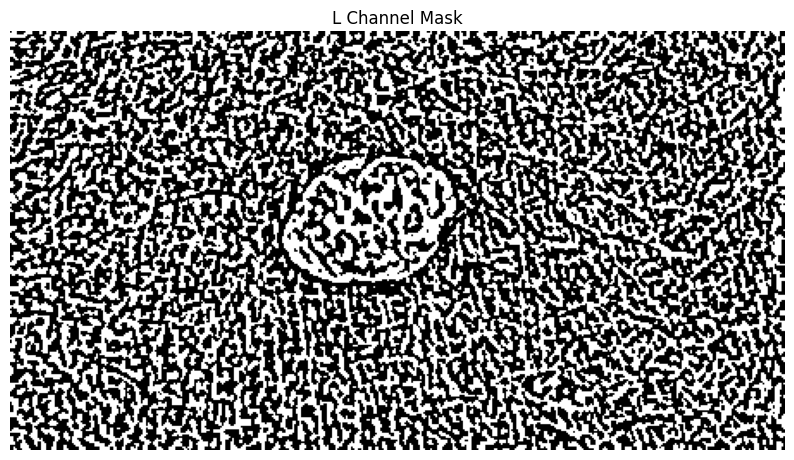

In [ ]:
# Cell 7: L-channel mask using adaptive thresholding
L_norm = cv2.normalize(L, None, 0, 255, cv2.NORM_MINMAX)
L_blur = cv2.GaussianBlur(L_norm, (5, 5), 0)  # Reduce noise and shine impact

# Use adaptive thresholding 
L_mask = cv2.adaptiveThreshold(L_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY_INV, 11, 2)

plt.imshow(L_mask, cmap='gray')
plt.title("L Channel Mask")
plt.axis('off')
plt.show()


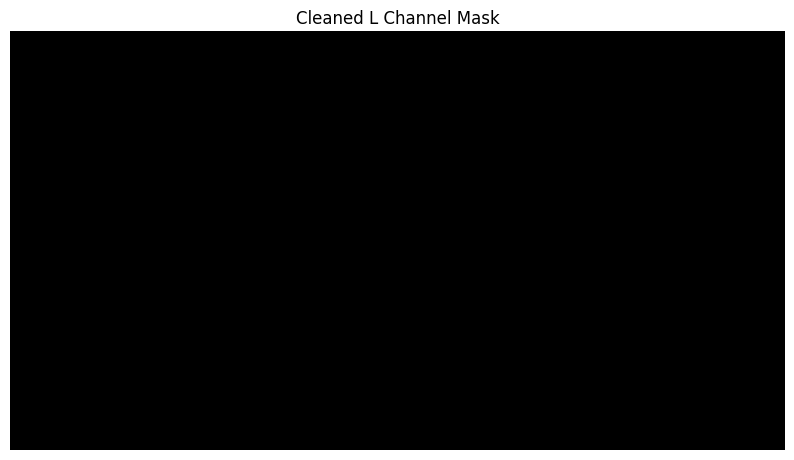

In [ ]:
#Cell 8: Morphological cleanup of L channel mask
#Opening and closing operations to clean up the mask
#kernel_close = np.ones((7,7), np.uint8)
#kernel_open = np.ones((5,5), np.uint8)

# Applying morphological closing and opening to fill holes and remove noise
L_mask_clean = cv2.morphologyEx(L_mask, cv2.MORPH_CLOSE, kernel_close)
L_mask_clean = cv2.morphologyEx(L_mask_clean, cv2.MORPH_OPEN, kernel_open)

plt.imshow(L_mask_clean, cmap='gray')
plt.title("Cleaned L Channel Mask")
plt.axis('off')
plt.show()


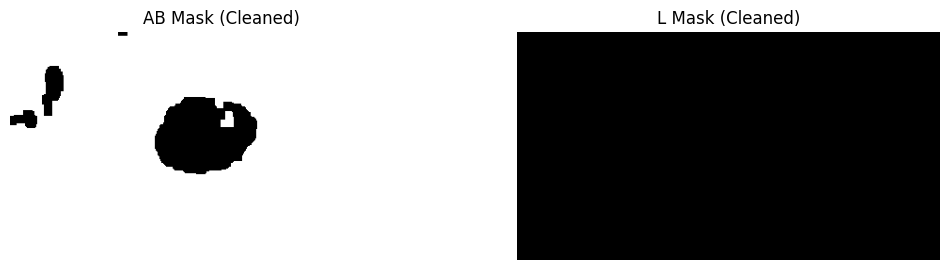

In [ ]:
# Cell 9: Displaying both cleaned masks side by side

# Plotting cleaned AB channel mask
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(AB_mask_clean, cmap='gray')
plt.title("AB Mask (Cleaned)")
plt.axis('off')

# Plotting cleaned L channel mask
plt.subplot(1,2,2)
plt.imshow(L_mask_clean, cmap='gray')
plt.title("L Mask (Cleaned)")
plt.axis('off')
plt.show()


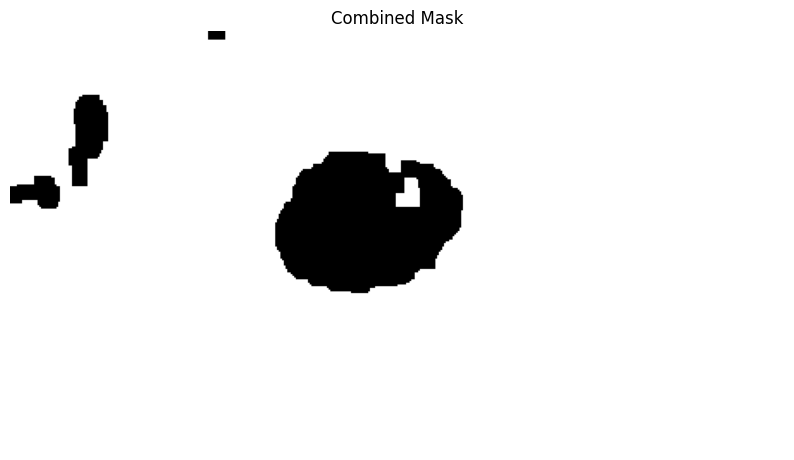

In [ ]:
combined_mask = cv2.bitwise_and(AB_mask_clean, L_mask_clean)

plt.imshow(combined_mask, cmap='gray')
plt.title("Combined Mask")
plt.axis('off')
plt.show()


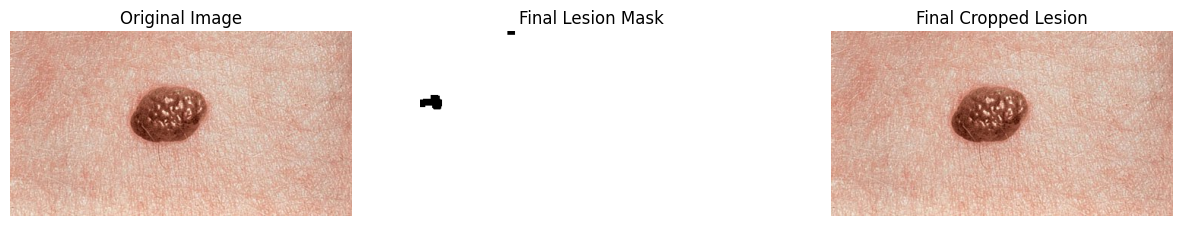

In [ ]:
# Cell 10: Optional tight crop of lesion from mask

contours, _ = cv2.findContours(combined_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if len(contours) > 0:
    largest_contour = max(contours, key=cv2.contourArea)
    lesion_mask_final = np.zeros_like(combined_mask)
    cv2.drawContours(lesion_mask_final, [largest_contour], -1, 255, -1)

    x, y, w_box, h_box = cv2.boundingRect(largest_contour)
    pad = 5
    x1 = max(x - pad, 0)
    y1 = max(y - pad, 0)
    x2 = min(x + w_box + pad, combined_mask.shape[1])
    y2 = min(y + h_box + pad, combined_mask.shape[0])

    lesion_crop_final = img[y1:y2, x1:x2]

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(lesion_mask_final, cmap='gray')
    plt.title("Final Lesion Mask")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(lesion_crop_final, cv2.COLOR_BGR2RGB))
    plt.title("Final Cropped Lesion")
    plt.axis('off')

    plt.show()


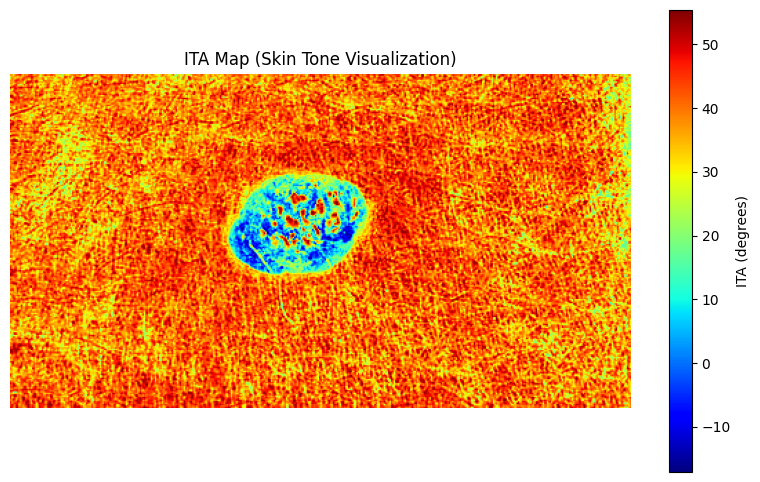

In [ ]:
# Cell 11: ITA map (skin tone visualization)

# Converting L and B channels to float for accurate computation
L_float = L.astype(np.float32)
B_float = B.astype(np.float32)
# Calculating ITA in degrees

ITA = np.arctan2((L_float - 50), B_float) * (180 / np.pi)

#Using jet colormap to visualize ITA values
plt.imshow(ITA, cmap='jet')
plt.colorbar(label='ITA (degrees)')
plt.title("ITA Map (Skin Tone Visualization)")
plt.axis('off')
plt.show()


In [ ]:
# Cell 12: Resize & Normalize for ML Model

# Resizing and normalizing the cropped lesion for model input
if len(contours) > 0:
    lesion_resized = cv2.resize(lesion_crop, (224, 224))
    lesion_normalized = lesion_resized / 255.0
    print("Lesion ready for model input:", lesion_normalized.shape)


NameError: name 'lesion_crop' is not defined

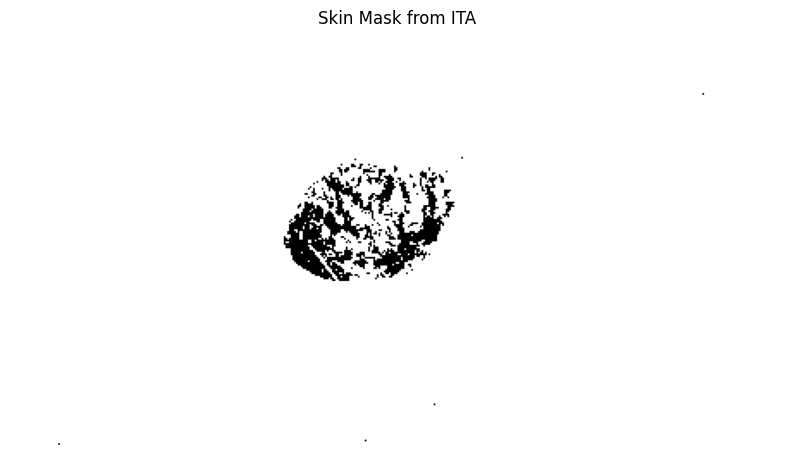

In [ ]:
# Define ITA thresholds for skin regions
skin_ita_low = 10
skin_ita_high = 55

# Create a mask for skin regions
skin_mask = np.where((ITA > skin_ita_low) & (ITA < skin_ita_high), 255, 0).astype(np.uint8)

plt.imshow(skin_mask, cmap='gray')
plt.title("Skin Mask from ITA")
plt.axis('off')
plt.show()


In [ ]:
# Calculate mean ITA for skin regions
mean_ita_skin = np.mean(ITA[skin_mask == 255])
print(f"Mean ITA for Skin Regions: {mean_ita_skin}")

# Classify skin tone based on ITA and Fitzpatrick Scale
if mean_ita_skin > 55:
    skin_tone = "Type I"
elif 41 < mean_ita_skin <= 55:
    skin_tone = "Type II"
elif 28 < mean_ita_skin <= 41:
    skin_tone = "Type III"
elif 10 < mean_ita_skin <= 28:
    skin_tone = "Type IV"
elif -30 < mean_ita_skin <= 10:
    skin_tone = "Type V"
else:
    skin_tone = "Type VI"

print(f"Skin Tone (Fitzpatrick Scale): {skin_tone}")


Mean ITA for Skin Regions: 39.284034729003906
Skin Tone (Fitzpatrick Scale): Type III


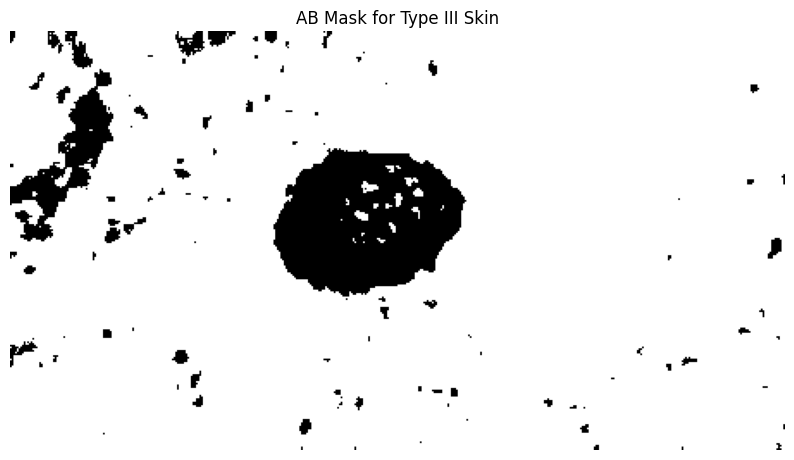

In [ ]:
def process_type_I_II(L, A, B):
    ab = np.stack([A, B], axis=2)
    ab_flat = ab.reshape((-1, 2))
    ab_flat = np.float32(ab_flat)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    K = 2
    _, labels, centers = cv2.kmeans(ab_flat, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    labels = labels.flatten().reshape(A.shape)

    cluster_means = [np.mean(L[labels == i]) for i in range(K)]
    lesion_cluster = np.argmin(cluster_means)

    AB_mask = np.uint8(labels == lesion_cluster) * 255
    return AB_mask

def process_type_III_IV(L, A, B):
    ab = np.stack([A, B], axis=2)
    ab_flat = ab.reshape((-1, 2))
    ab_flat = np.float32(ab_flat)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    K = 3
    _, labels, centers = cv2.kmeans(ab_flat, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    labels = labels.flatten().reshape(A.shape)

    cluster_means = [np.mean(L[labels == i]) for i in range(K)]
    lesion_cluster = np.argmin(cluster_means)

    AB_mask = np.uint8(labels == lesion_cluster) * 255
    AB_mask = 255 - AB_mask  # Invert the mask for medium skin tones
    return AB_mask

def process_type_V_VI(L, A, B):
    ab = np.stack([A, B], axis=2)
    ab_flat = ab.reshape((-1, 2))
    ab_flat = np.float32(ab_flat)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    K = 3
    _, labels, centers = cv2.kmeans(ab_flat, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    labels = labels.flatten().reshape(A.shape)

    cluster_means = [np.mean(L[labels == i]) for i in range(K)]
    lesion_cluster = np.argmin(cluster_means)

    AB_mask = np.uint8(labels == lesion_cluster) * 255
    AB_mask = 255 - AB_mask  # Invert the mask for dark skin tones
    return AB_mask

# Apply skin tone-specific processing
if skin_tone in ["Type I", "Type II"]:
    AB_mask = process_type_I_II(L, A, B)
elif skin_tone in ["Type III", "Type IV"]:
    AB_mask = process_type_III_IV(L, A, B)
else:  # Type V and Type VI
    AB_mask = process_type_V_VI(L, A, B)

plt.imshow(AB_mask, cmap='gray')
plt.title(f"AB Mask for {skin_tone} Skin")
plt.axis('off')
plt.show()


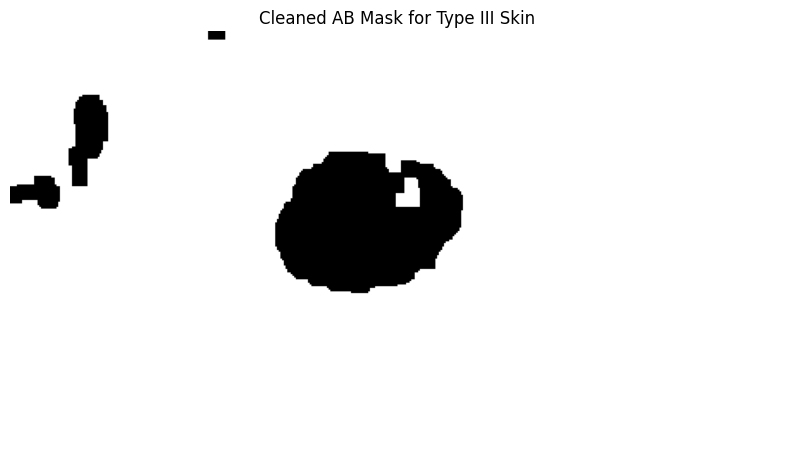

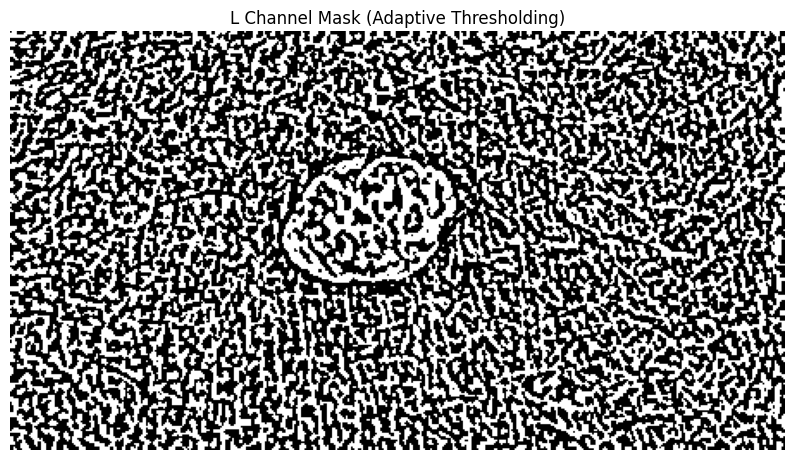

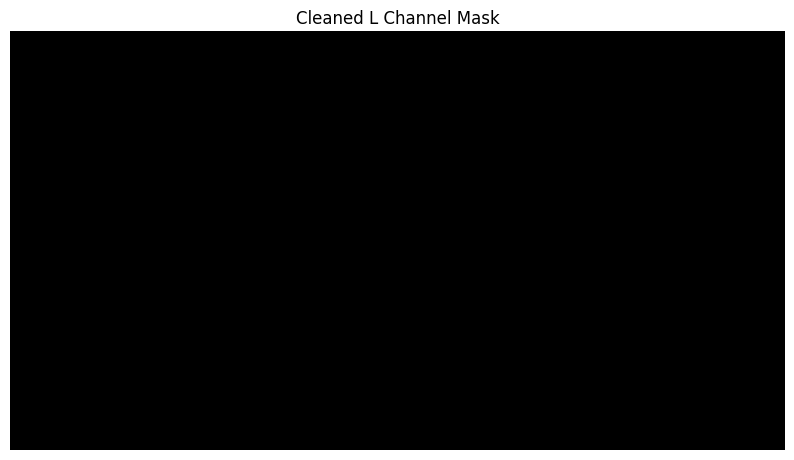

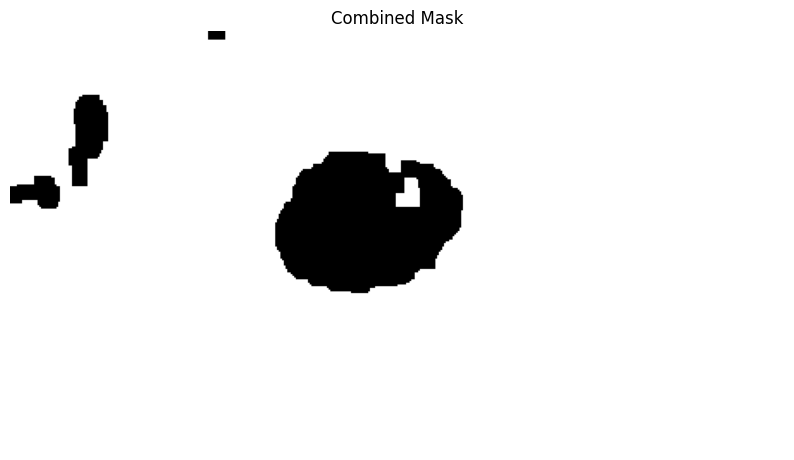

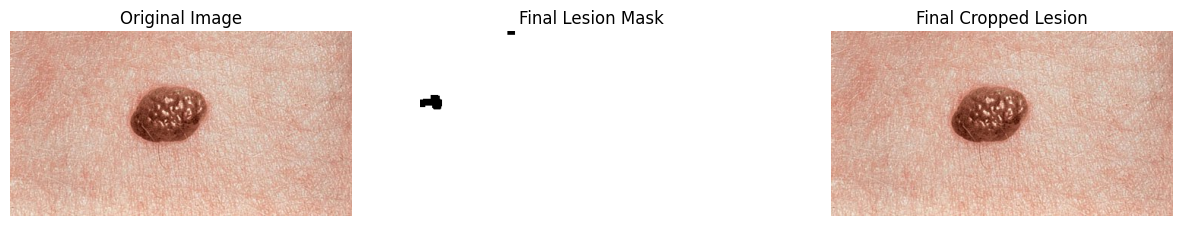

In [ ]:
# Morphological cleanup
kernel_close = np.ones((9, 9), np.uint8)
kernel_open = np.ones((7, 7), np.uint8)

AB_mask_clean = cv2.morphologyEx(AB_mask, cv2.MORPH_CLOSE, kernel_close)
AB_mask_clean = cv2.morphologyEx(AB_mask_clean, cv2.MORPH_OPEN, kernel_open)

plt.imshow(AB_mask_clean, cmap='gray')
plt.title(f"Cleaned AB Mask for {skin_tone} Skin")
plt.axis('off')
plt.show()

# L-Channel Mask with Adaptive Thresholding
L_norm = cv2.normalize(L, None, 0, 255, cv2.NORM_MINMAX)
L_blur = cv2.GaussianBlur(L_norm, (5, 5), 0)

L_mask = cv2.adaptiveThreshold(L_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY_INV, 11, 2)

plt.imshow(L_mask, cmap='gray')
plt.title("L Channel Mask (Adaptive Thresholding)")
plt.axis('off')
plt.show()

# Morphological cleanup of L-Channel Mask
L_mask_clean = cv2.morphologyEx(L_mask, cv2.MORPH_CLOSE, kernel_close)
L_mask_clean = cv2.morphologyEx(L_mask_clean, cv2.MORPH_OPEN, kernel_open)

plt.imshow(L_mask_clean, cmap='gray')
plt.title("Cleaned L Channel Mask")
plt.axis('off')
plt.show()

# Combine Masks
combined_mask = cv2.bitwise_and(AB_mask_clean, L_mask_clean)

plt.imshow(combined_mask, cmap='gray')
plt.title("Combined Mask")
plt.axis('off')
plt.show()

# Find Contours and Crop Lesion
contours, _ = cv2.findContours(combined_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if len(contours) > 0:
    largest_contour = max(contours, key=cv2.contourArea)
    lesion_mask_final = np.zeros_like(combined_mask)
    cv2.drawContours(lesion_mask_final, [largest_contour], -1, 255, -1)

    x, y, w_box, h_box = cv2.boundingRect(largest_contour)
    pad = 5
    x1 = max(x - pad, 0)
    y1 = max(y - pad, 0)
    x2 = min(x + w_box + pad, combined_mask.shape[1])
    y2 = min(y + h_box + pad, combined_mask.shape[0])

    lesion_crop_final = img[y1:y2, x1:x2]

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(lesion_mask_final, cmap='gray')
    plt.title("Final Lesion Mask")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(lesion_crop_final, cv2.COLOR_BGR2RGB))
    plt.title("Final Cropped Lesion")
    plt.axis('off')

    plt.show()
